## 1. Stats on overlap percentage for chunk level hits

for each GT, it's possible multiple retrieved chunks overlaps with here, here we only consider the "best" one i.e. the one chunk that have max overlap range with the GT

In [129]:
import statistics
import json
import matplotlib.pyplot as plt
from pathlib import Path

def overlap_summary(data: dict, label: str = "") -> None:
    pgt = data["pct_of_gt"]
    pch = data.get("pct_of_chunk")
    n = len(pgt)
    if not n:
        print(f"{'─'*52}")
        return
    has_chunk = pch is not None and len(pch) == n
    if label:
        header = f"  {'':22}  {'pct_of_gt':>10}"
        if has_chunk:
            header += f"  {'pct_of_chunk':>12}"
        print(f"\n  {label}  (n={n} hit GTs)")
        print(header)
    for stat, fn in [("mean", statistics.mean), ("median", statistics.median)]:
        row = f"  {stat:22}  {fn(pgt):10.1f}"
        if has_chunk:
            row += f"  {fn(pch):12.1f}"
        print(row)
    for thr in (50, 80):
        label_str = f"% hits with overlap >{thr}%"
        row = f"  {label_str:22}  {sum(v > thr for v in pgt) / n * 100:10.1f}"
        if has_chunk:
            row += f"  {sum(v > thr for v in pch) / n * 100:12.1f}"
        print(row)


def plot_overlap_hist(
    data: dict,
    *,
    title: str = "Overlap distribution — chunk-level hits",
    bins: int = 20,
    figsize: tuple[float, float] = (11, 4),
    save_to: str | Path | None = None,
    fmt: str = "png",
) -> None:
    """
    If data contains pct_of_chunk: two panels (GT coverage | chunk coverage).
    If data only has pct_of_gt (union output): single panel.
    Y-axis is always % of hit GTs.
    """
    pgt = data["pct_of_gt"]
    pch = data.get("pct_of_chunk")
    has_chunk = pch is not None and len(pch) == len(pgt)
    n = len(pgt)

    panels = [(pgt, "blue", "GT coverage % (union)" if not has_chunk else "Best overlap % of GT snippet",
               "GT coverage (union across chunks)" if not has_chunk else "GT coverage (best chunk per GT)")]
    if has_chunk:
        panels.append((pch, "orange", "Overlap % of retrieved chunk", "Chunk coverage per hit"))

    ncols = len(panels)
    fig_w = figsize[0] if has_chunk else figsize[0] / 2
    fig, axes = plt.subplots(1, ncols, figsize=(fig_w, figsize[1]))
    if ncols == 1:
        axes = [axes]

    for ax, (vals, color, xlabel, panel_title) in zip(axes, panels):
        weights = [100 / len(vals)] * len(vals) if vals else []
        ax.hist(vals, bins=bins, range=(0, 100), color=color, edgecolor="white",
                linewidth=0.5, weights=weights)
        med = statistics.median(vals) if vals else 0
        ax.axvline(med, color="red", linestyle="--", linewidth=1.5, label=f"median {med:.1f}%")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("% of hit GTs")
        ax.set_title(panel_title)
        ax.set_xlim(0, 100)
        ax.legend(fontsize=8)

    fig.suptitle(f"{title}", fontsize=12, fontweight="bold")
    fig.tight_layout()
    if save_to:
        dest = Path(save_to).with_suffix(f".{fmt}")
        dest.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(dest)
        print(f"Saved → {dest}")
    plt.show()


In [130]:
# ── Overlap analysis ──────────────────────────────────────────────────────────

BENCH_NAMES = {"contractnli", "cuad", "maud", "privacy_qa"}

def load_overlap_data(trace_path: str | Path, k: int) -> dict:
    """
    For each hit GT, record the BEST single-chunk pct_of_gt and its paired
    pct_of_chunk (i.e. how much of that chunk falls inside the GT).

    Returns dict with three parallel lists:
      pct_of_gt    — best overlap % of GT snippet (max across chunks)
      pct_of_chunk — % of that best chunk that falls inside the GT
      benchmark    — which benchmark the query came from
    """
    pct_of_gt, pct_of_chunk, benchmarks = [], [], []
    with open(trace_path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if rec.get("_type") == "run_summary":
                continue
            bm = next((t for t in rec.get("tags", []) if t in BENCH_NAMES), "unknown")
            for k_rec in rec.get("metrics_by_k", []):
                if k_rec["k"] != k:
                    continue
                best: dict[int, tuple[float, float]] = {}  # gt_idx → (pct_of_gt, pct_of_chunk)
                for chunk in k_rec.get("chunk_hits", []):
                    for ov in chunk.get("gt_overlaps", []):
                        g = ov["gt_idx"]
                        if g not in best or ov["overlap_pct_of_gt"] > best[g][0]:
                            best[g] = (ov["overlap_pct_of_gt"], ov["overlap_pct_of_chunk"])
                for pgt, pch in best.values():
                    pct_of_gt.append(pgt)
                    pct_of_chunk.append(pch)
                    benchmarks.append(bm)
    return {"pct_of_gt": pct_of_gt, "pct_of_chunk": pct_of_chunk, "benchmark": benchmarks}


def _union_coverage(spans: list[tuple[int, int]], gt_start: int, gt_end: int) -> float:
    """Fraction of [gt_start, gt_end) covered by the union of overlap spans (0–100)."""
    gt_len = max(1, gt_end - gt_start)
    if not spans:
        return 0.0
    merged = sorted(spans)
    cur_s, cur_e = merged[0]
    covered = 0
    for s, e in merged[1:]:
        if s <= cur_e:
            cur_e = max(cur_e, e)
        else:
            covered += cur_e - cur_s
            cur_s, cur_e = s, e
    covered += cur_e - cur_s
    return covered / gt_len * 100


def load_overlap_data_union(trace_path: str | Path, k: int) -> dict:
    """
    For each hit GT, compute UNION coverage — the merged span of all top-k
    chunks that overlap it, expressed as % of GT length.

    This captures tiling: two chunks covering different halves of a GT give
    100% union coverage but only 50% under the max approach.

    Returns dict with two parallel lists:
      pct_of_gt  — union overlap % of GT covered by any retrieved chunk
      benchmark  — which benchmark the query came from
    """
    # # Old max approach (kept for reference):
    # for chunk in k_rec["chunk_hits"]:
    #     for ov in chunk["gt_overlaps"]:
    #         g = ov["gt_idx"]
    #         if g not in best or ov["overlap_pct_of_gt"] > best[g][0]:
    #             best[g] = (ov["overlap_pct_of_gt"], ov["overlap_pct_of_chunk"])

    pct_of_gt, benchmarks = [], []
    with open(trace_path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if rec.get("_type") == "run_summary":
                continue
            bm = next((t for t in rec.get("tags", []) if t in BENCH_NAMES), "unknown")
            for k_rec in rec.get("metrics_by_k", []):
                if k_rec["k"] != k:
                    continue
                gt_spans: dict[int, list[tuple[int, int]]] = {}
                gt_bounds: dict[int, tuple[int, int]] = {}
                for chunk in k_rec.get("chunk_hits", []):
                    for ov in chunk.get("gt_overlaps", []):
                        g = ov["gt_idx"]
                        if g not in gt_spans:
                            gt_spans[g] = []
                            gt_bounds[g] = tuple(rec["ground_truth"][g]["span"])
                        gt_spans[g].append(tuple(ov["overlap_span"]))
                for g, spans in gt_spans.items():
                    gt_start, gt_end = gt_bounds[g]
                    pct_of_gt.append(_union_coverage(spans, gt_start, gt_end))
                    benchmarks.append(bm)
    return {"pct_of_gt": pct_of_gt, "benchmark": benchmarks}


def load_chunk_precision_data(trace_path: str | Path, k: int) -> dict:
    """
    For each retrieved chunk that is a hit, record pct_of_chunk —
    how much of that chunk falls inside any GT snippet.

    When a chunk overlaps multiple GTs, takes the max pct_of_chunk.

    Returns dict with two parallel lists:
      pct_of_chunk — % of the chunk that falls inside a GT snippet
      benchmark    — which benchmark the query came from
    """
    pct_of_chunk, benchmarks = [], []
    with open(trace_path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if rec.get("_type") == "run_summary":
                continue
            bm = next((t for t in rec.get("tags", []) if t in BENCH_NAMES), "unknown")
            for k_rec in rec.get("metrics_by_k", []):
                if k_rec["k"] != k:
                    continue
                for chunk in k_rec.get("chunk_hits", []):
                    overlaps = chunk.get("gt_overlaps", [])
                    if not overlaps:
                        continue
                    best_pch = max(ov["overlap_pct_of_chunk"] for ov in overlaps)
                    pct_of_chunk.append(best_pch)
                    benchmarks.append(bm)
    return {"pct_of_chunk": pct_of_chunk, "benchmark": benchmarks}


In [131]:
EVAL_ROOT = Path("logs/eval")
QUERY_TYPE = ['original', 'gemini_3', 'qwen3.5']


  all mpnet base v2 – original queries  (n=148 hit GTs)
                           pct_of_gt  pct_of_chunk
  mean                          72.5          53.3
  median                        82.7          51.2
  % hits with overlap >50%        77.0          50.7
  % hits with overlap >80%        53.4          23.0


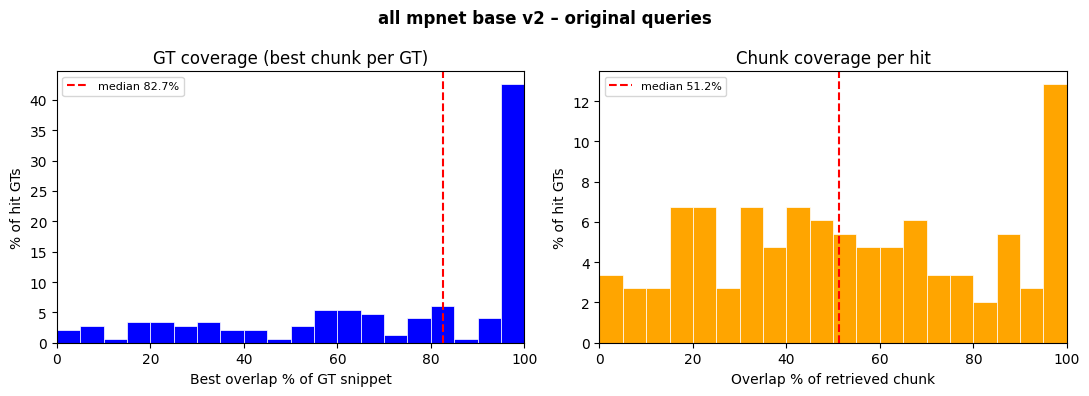

In [132]:
# ======== old logic, take the max pct_of_gt for every gt =============
#  K=60, original queries, all-mpnet model
data = load_overlap_data(
    EVAL_ROOT / QUERY_TYPE[0] / "lbr_hier_all-mpnet.jsonl",
    k=60,
)

overlap_summary(data, label="all mpnet base v2 – original queries")

plot_overlap_hist(
    data,
    title="all mpnet base v2 – original queries",
    #save_to=EVAL_ROOT / QUERY_TYPE[0] / "figures" / "overlap_hist_all-mpnet_k20",
)


  all mpnet base v2 – original queries  (n=148 hit GTs)
                           pct_of_gt
  mean                          78.1
  median                       100.0
  % hits with overlap >50%        77.7
  % hits with overlap >80%        63.5


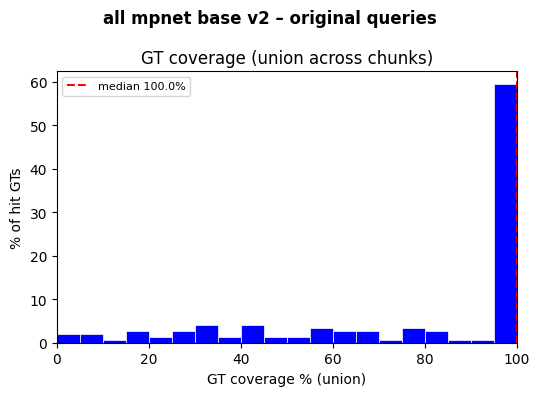

In [133]:
# ============= new logic, for every GT take the union of hit chunks in top k ===========
# K=60, original queries, all-mpnet model
data = load_overlap_data_union(
    EVAL_ROOT / QUERY_TYPE[0] / "lbr_hier_all-mpnet.jsonl",
    k=60,
)

overlap_summary(data, label="all mpnet base v2 – original queries")

plot_overlap_hist(
    data,
    title="all mpnet base v2 – original queries",
    #save_to=EVAL_ROOT / QUERY_TYPE[0] / "figures" / "overlap_hist_all-mpnet_k20",
)


  qwen3 – original queries  (n=140 hit GTs)
                           pct_of_gt  pct_of_chunk
  mean                          69.8          52.6
  median                        78.5          49.9
  % hits with overlap >50%        74.3          50.0
  % hits with overlap >80%        48.6          24.3


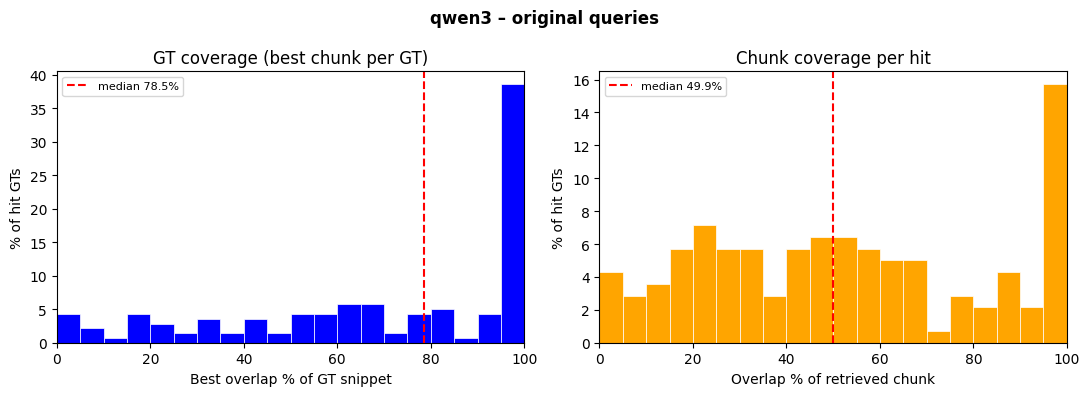

In [134]:
#  K=60, original queries, qwen3 model
data = load_overlap_data(
    EVAL_ROOT / QUERY_TYPE[0] / "lbr_hier_qwen3.jsonl",
    k=60,
)

overlap_summary(data, label="qwen3 – original queries")

plot_overlap_hist(
    data,
    title="qwen3 – original queries",
    #save_to=EVAL_ROOT / QUERY_TYPE[0] / "figures" / "overlap_hist_all-mpnet_k20",
)

# GT coverage stats

In [ ]:
# ── GT coverage stats ─────────────────────────────────────────────────────────
# For each benchmark and K:
#   - total GT snippets across all queries
#   - # queries where ALL GTs are covered (chunk_recall == 1.0) → "perfect recall"
#   - # queries where NO GT is covered (chunk_recall == 0.0)    → "zero recall"

from collections import defaultdict

def gt_coverage_stats(trace_path: str | Path, ks: list[int]) -> dict:
    """
    Returns a dict keyed by benchmark name (+ "OVERALL") with per-K stats:
      n_queries       — total queries for this benchmark
      total_gt        — total GT snippets across all queries
      perfect_recall  — queries where every GT snippet was hit (recall == 1.0)
      zero_recall     — queries where no GT snippet was hit (recall == 0.0)
    """
    # per_bm[bm][k] = {"n_queries", "total_gt", "perfect", "zero"}
    per_bm: dict[str, dict[int, dict]] = defaultdict(
        lambda: {k: {"n_queries": 0, "total_gt": 0, "perfect": 0, "zero": 0} for k in ks}
    )

    with open(trace_path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if rec.get("_type") == "run_summary":
                continue
            bm = next((t for t in rec.get("tags", []) if t in BENCH_NAMES), "unknown")
            for k_rec in rec.get("metrics_by_k", []):
                if k_rec["k"] not in ks:
                    continue
                k = k_rec["k"]
                n_gt  = k_rec["n_gt_snippets"]
                n_hit = k_rec["n_gt_hit"] # each GT is counted once so no need to worry about double counting
                per_bm[bm][k]["n_queries"] += 1
                per_bm[bm][k]["total_gt"]  += n_gt
                if n_hit == n_gt: 
                    per_bm[bm][k]["perfect"] += 1
                if n_hit == 0:
                    per_bm[bm][k]["zero"] += 1

    return per_bm


def print_gt_coverage(trace_path: str | Path, ks: list[int]) -> None:
    per_bm = gt_coverage_stats(trace_path, ks)
    # print(per_bm)
    bm_names = [b for b in ("contractnli", "cuad", "maud", "privacy_qa") if b in per_bm]

    col_w = 9
    k_header = "  ".join(f"{'K='+str(k):>{col_w}}" for k in ks)
    width = 20 + (col_w + 2) * len(ks)

    def fmt_row(label, vals):
        return f"  {label:<18}  " + "  ".join(f"{v:>{col_w}}" for v in vals)

    for stat_key, title, desc in [
        ("total_gt",  "Total GT snippets per benchmark",
         "Sum of GT snippets across all queries"),
        ("n_queries", "Total queries per benchmark",
         "Number of queries evaluated"),
        ("perfect",   "Queries with ALL GTs covered (perfect recall@K)",
         "Every GT snippet hit by at least one of the top-K chunks"),
        ("zero",      "Queries with NO GT covered (zero recall@K)",
         "No GT snippet hit by any of the top-K chunks"),
    ]:
        print(f"\n{'─'*width}")
        print(f"  {title}")
        print(f"  {desc}")
        print(f"{'─'*width}")
        # for total_gt and n_queries, K doesn't matter — just use first K
        if stat_key in ("total_gt", "n_queries"):
            print(f"  {'Benchmark':<18}  {'value':>{col_w}}")
            print(f"  {'─'*18}  {'─'*col_w}")
            total = 0
            for bm in bm_names:
                v = per_bm[bm][ks[0]][stat_key]
                total += v
                print(f"  {bm:<18}  {v:>{col_w}}")
            print(f"  {'─'*18}  {'─'*col_w}")
            print(f"  {'TOTAL':<18}  {total:>{col_w}}")
        else:
            print(f"  {'Benchmark':<18}  {k_header}")
            print(f"  {'─'*18}  {'  '.join(['─'*col_w]*len(ks))}")
            overall_pct = []
            for bm in bm_names:
                n_q = per_bm[bm][ks[0]]["n_queries"]
                vals = []
                for k in ks:
                    v = per_bm[bm][k][stat_key]
                    vals.append(f"{v}/{n_q} ({100*v/n_q:.0f}%)" if n_q else "—")
                print(fmt_row(bm, vals))
            # overall: sum across benchmarks
            print(f"  {'─'*18}  {'  '.join(['─'*col_w]*len(ks))}")
            total_q = sum(per_bm[bm][ks[0]]["n_queries"] for bm in bm_names)
            vals = []
            for k in ks:
                v = sum(per_bm[bm][k][stat_key] for bm in bm_names)
                vals.append(f"{v}/{total_q} ({100*v/total_q:.0f}%)" if total_q else "—")
            print(fmt_row("OVERALL", vals))


In [136]:
print_gt_coverage(
    EVAL_ROOT / QUERY_TYPE[0] / "lbr_hier_all-mpnet.jsonl",
    ks=[20, 40, 60],
)



─────────────────────────────────────────────────────
  Total GT snippets per benchmark
  Sum of GT snippets across all queries
─────────────────────────────────────────────────────
  Benchmark               value
  ──────────────────  ─────────
  contractnli                70
  cuad                      100
  maud                       76
  privacy_qa                116
  ──────────────────  ─────────
  TOTAL                     362

─────────────────────────────────────────────────────
  Total queries per benchmark
  Number of queries evaluated
─────────────────────────────────────────────────────
  Benchmark               value
  ──────────────────  ─────────
  contractnli                50
  cuad                       50
  maud                       50
  privacy_qa                 50
  ──────────────────  ─────────
  TOTAL                     200

─────────────────────────────────────────────────────
  Queries with ALL GTs covered (perfect recall@K)
  Every GT snippet hit by at le

# multi-hit GT

In [137]:
# ── 1. Multi-hit GT analysis ──────────────────────────────────────────────────
# A single GT snippet may be partially covered by several retrieved chunks.
# We only count it as one hit in metrics, but the trace records every overlap.
# This cell surfaces those cases.

from collections import defaultdict

def load_multi_hit_records(trace_path: str | Path, k: int) -> list[dict]:
    """
    Return one record per (query, gt_idx) pair where 2+ retrieved chunks overlap
    with the same GT snippet at cutoff k.

    Each record:
      query        — query string
      benchmark    — benchmark name
      gt           — {'file', 'span'}
      gt_idx       — index within this query's GT list
      chunks       — list of overlapping chunks, each with rank, char_start,
                     char_end, score, overlap_pct_of_gt, overlap_pct_of_chunk
    """
    records = []
    with open(trace_path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if rec.get("_type") == "run_summary":
                continue
            bm = next((t for t in rec.get("tags", []) if t in BENCH_NAMES), "unknown")
            for k_rec in rec.get("metrics_by_k", []):
                if k_rec["k"] != k:
                    continue
                # group chunks by gt_idx
                gt_to_chunks: dict[int, list] = defaultdict(list)
                for ch in k_rec.get("chunk_hits", []):
                    for ov in ch.get("gt_overlaps", []):
                        gt_to_chunks[ov["gt_idx"]].append({
                            "rank": ch["rank"],
                            "file": ch["file"],
                            "char_start": ch["char_start"],
                            "char_end": ch["char_end"],
                            "score": ch["score"],
                            "overlap_span": ov["overlap_span"],
                            "overlap_pct_of_gt": ov["overlap_pct_of_gt"],
                            "overlap_pct_of_chunk": ov["overlap_pct_of_chunk"],
                        })
                for gt_idx, chunks in gt_to_chunks.items():
                    if len(chunks) > 1:
                        records.append({
                            "query": rec["query"],
                            "benchmark": bm,
                            "gt": rec["ground_truth"][gt_idx],
                            "gt_idx": gt_idx,
                            "n_gt_total": len(rec["ground_truth"]),
                            "chunks": sorted(chunks, key=lambda c: c["rank"]),
                        })
    return records


def multi_hit_summary(records: list[dict], label: str = "") -> None:
    from collections import Counter
    if label:
        print(f"\n{'─'*60}")
        print(f"  Multi-hit GT analysis — {label}  (n={len(records)} cases)")
        print(f"{'─'*60}")
    hit_counts = Counter(len(r["chunks"]) for r in records)
    print("  Chunks per GT  |  # cases")
    for n_chunks in sorted(hit_counts):
        print(f"  {n_chunks:14d}  |  {hit_counts[n_chunks]}")
    # cumulative pct_of_gt across all overlapping chunks for each GT
    combined_pgt = [sum(c["overlap_pct_of_gt"] for c in r["chunks"]) for r in records]
    print(f"\n  Combined pct_of_gt (sum across chunks hitting same GT):")
    print(f"    mean   = {statistics.mean(combined_pgt):.1f}%")
    print(f"    median = {statistics.median(combined_pgt):.1f}%")
    print(f"    > 100% (chunks collectively over-cover GT): "
          f"{sum(v>100 for v in combined_pgt)} / {len(combined_pgt)}")


def show_multi_hit_cases(records: list[dict], n: int = 5, corpus_root: str | Path = "data/LegalBenchRAG/corpus") -> None:
    """Print the first n multi-hit cases with GT text and each overlapping chunk."""
    corpus_root = Path(corpus_root)
    for r in records[:n]:
        gt = r["gt"]
        gt_file = corpus_root / gt["file"]
        gt_start, gt_end = gt["span"]
        try:
            doc_text = gt_file.read_text(encoding="utf-8", errors="replace")
            gt_text = doc_text[gt_start:gt_end]
        except FileNotFoundError:
            gt_text = "<file not found>"
            doc_text = ""
        print(f"\n{'═'*70}")
        print(f"  Benchmark : {r['benchmark']}")
        print(f"  Query     : {r['query'][:200]}")
        print(f"  GT [{r['gt_idx']+1}/{r['n_gt_total']}]  : chars {gt_start}–{gt_end}  "
              f"({gt_end - gt_start} chars)")
        print(f"  GT text   : {gt_text.replace(chr(10), ' ')}")
        print(f"  ── {len(r['chunks'])} overlapping chunks ──")
        for ch in r["chunks"]:
            try:
                ch_file = corpus_root / ch["file"]
                ch_text = ch_file.read_text(encoding="utf-8", errors="replace")[ch["char_start"]:ch["char_end"]]
            except FileNotFoundError:
                ch_text = "<file not found>"
            overlap_text = doc_text[ch["overlap_span"][0]:ch["overlap_span"][1]] if doc_text else ""
            print(f"  Rank {ch['rank']:3d}  score={ch['score']:.4f}  "
                  f"chars {ch['char_start']}–{ch['char_end']}  "
                  f"pct_of_gt={ch['overlap_pct_of_gt']:.1f}%  "
                  f"pct_of_chunk={ch['overlap_pct_of_chunk']:.1f}%")
            print(f"    overlap text : {overlap_text.replace(chr(10), ' ')}")
            print(f"    chunk text   : {ch_text.replace(chr(10), ' ')}")


In [138]:
# sentence transformer
multi_hit_recs = load_multi_hit_records(
    EVAL_ROOT / QUERY_TYPE[0] / "lbr_hier_all-mpnet.jsonl",
    k=60,
)

multi_hit_summary(multi_hit_recs, label="all-mpnet k=60")

show_multi_hit_cases(multi_hit_recs, n=5)



────────────────────────────────────────────────────────────
  Multi-hit GT analysis — all-mpnet k=60  (n=57 cases)
────────────────────────────────────────────────────────────
  Chunks per GT  |  # cases
               2  |  48
               3  |  7
               4  |  1
               6  |  1

  Combined pct_of_gt (sum across chunks hitting same GT):
    mean   = 98.8%
    median = 107.5%
    > 100% (chunks collectively over-cover GT): 36 / 57

══════════════════════════════════════════════════════════════════════
  Benchmark : contractnli
  Query     : Consider Grindrod SA's Non-Disclosure Agreement; Does the document state that Confidential Information shall only include technical information?
  GT [1/1]  : chars 757–1492  (735 chars)
  GT text   : 1.1 “Confidential Information” means; all technical, commercial, procurement requirements, purchasing, manufacturing, customer lists, investors, employees, business and contractual relationships, business forecasts, sales and merchand

In [139]:
# sort by the len(chunks) to find the most extreme case
extreme = max(multi_hit_recs, key=lambda r: len(r["chunks"]))
print(len(extreme['chunks']))
extreme

6


{'query': 'Consider "Groupon"\'s privacy policy; what does groupon do with collected data? (eg, does it sell it to third parties?)',
 'benchmark': 'privacy_qa',
 'gt': {'file': 'privacy_qa/Groupon.txt', 'span': [4089, 9287]},
 'gt_idx': 0,
 'n_gt_total': 2,
 'chunks': [{'rank': 9,
   'file': 'privacy_qa/Groupon.txt',
   'char_start': 9286,
   'char_end': 9798,
   'score': 0.027492668,
   'overlap_span': [9286, 9287],
   'overlap_pct_of_gt': 0.02,
   'overlap_pct_of_chunk': 0.2},
  {'rank': 12,
   'file': 'privacy_qa/Groupon.txt',
   'char_start': 6007,
   'char_end': 6419,
   'score': 0.02707152,
   'overlap_span': [6007, 6419],
   'overlap_pct_of_gt': 7.93,
   'overlap_pct_of_chunk': 100.0},
  {'rank': 23,
   'file': 'privacy_qa/Groupon.txt',
   'char_start': 8211,
   'char_end': 8723,
   'score': 0.02333469,
   'overlap_span': [8211, 8723],
   'overlap_pct_of_gt': 9.85,
   'overlap_pct_of_chunk': 100.0},
  {'rank': 26,
   'file': 'privacy_qa/Groupon.txt',
   'char_start': 8659,
   'c

In [140]:
# qwen 3
multi_hit_recs = load_multi_hit_records(
    EVAL_ROOT / QUERY_TYPE[0] / "lbr_hier_qwen3.jsonl",
    k=60,
)

multi_hit_summary(multi_hit_recs, label="qwen3 k=60")

show_multi_hit_cases(multi_hit_recs, n=5)


────────────────────────────────────────────────────────────
  Multi-hit GT analysis — qwen3 k=60  (n=48 cases)
────────────────────────────────────────────────────────────
  Chunks per GT  |  # cases
               2  |  35
               3  |  11
               4  |  1
               8  |  1

  Combined pct_of_gt (sum across chunks hitting same GT):
    mean   = 97.2%
    median = 109.0%
    > 100% (chunks collectively over-cover GT): 32 / 48

══════════════════════════════════════════════════════════════════════
  Benchmark : contractnli
  Query     : Consider Grindrod SA's Non-Disclosure Agreement; Does the document state that Confidential Information shall only include technical information?
  GT [1/1]  : chars 757–1492  (735 chars)
  GT text   : 1.1 “Confidential Information” means; all technical, commercial, procurement requirements, purchasing, manufacturing, customer lists, investors, employees, business and contractual relationships, business forecasts, sales and merchandisi

# 3. Low-overlap deep dive

In [141]:
# When a GT snippet's BEST chunk overlap is < threshold, the system barely
# found it.  We filter at GT level so a GT with one 4%-overlap chunk and 
# one 90%-overlap chunk is NOT flagged — only GTs
# where every overlapping chunk covers < threshold% of the GT are included.
#
# Text is fetched from OpenSearch (one mget per case) rather than reading
# corpus files -> exactly what was indexed.

from legalrag.opensearch.client import OpenSearchClient

def _make_os_client(index: str) -> OpenSearchClient:
    from legalrag.core.config import settings
    client = OpenSearchClient(cfg=settings.opensearch, embedding_dim=settings.embedding.dim)
    client.index_name = index
    return client


def load_low_overlap_cases(
    trace_path: str | Path,
    k: int,
    threshold: float = 5.0,
) -> list[dict]:
    """
    Return one record per GT snippet whose best pct_of_gt across all
    overlapping chunks at cutoff k is still below `threshold`.

    Each record:
      query              — query string
      benchmark          — benchmark name
      gt                 — {'file', 'span'}
      gt_idx             — GT index within this query
      n_gt_total         — total number of GT snippets for this query
      best_pct_of_gt     — max overlap_pct_of_gt achieved by any chunk
      overlapping_chunks — all chunks that touched this GT, sorted by
                           overlap_pct_of_gt desc; each has rank, file,
                           char_start, char_end, score, overlap_span,
                           overlap_pct_of_gt, overlap_pct_of_chunk
      retrieved_all      — top-k retrieved chunks for context
      ground_truth       — all GT snippets for this query
    """
    cases = []
    with open(trace_path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if rec.get("_type") == "run_summary":
                continue
            bm = next((t for t in rec.get("tags", []) if t in BENCH_NAMES), "unknown")
            for k_rec in rec.get("metrics_by_k", []):
                if k_rec["k"] != k:
                    continue
                gt_chunks: dict[int, list] = {}
                for ch in k_rec.get("chunk_hits", []):
                    for ov in ch.get("gt_overlaps", []):
                        g = ov["gt_idx"]
                        if g not in gt_chunks:
                            gt_chunks[g] = []
                        gt_chunks[g].append({
                            "rank": ch["rank"],
                            "file": ch["file"],
                            "char_start": ch["char_start"],
                            "char_end": ch["char_end"],
                            "score": ch["score"],
                            "chunk_id": ch["chunk_id"],
                            "overlap_span": ov["overlap_span"],
                            "overlap_pct_of_gt": ov["overlap_pct_of_gt"],
                            "overlap_pct_of_chunk": ov["overlap_pct_of_chunk"],
                        })
                for gt_idx, chunks in gt_chunks.items():
                    best_pct = max(c["overlap_pct_of_gt"] for c in chunks)
                    if best_pct < threshold:
                        cases.append({
                            "query": rec["query"],
                            "benchmark": bm,
                            "gt": rec["ground_truth"][gt_idx],
                            "gt_idx": gt_idx,
                            "n_gt_total": len(rec["ground_truth"]),
                            "best_pct_of_gt": best_pct,
                            "overlapping_chunks": sorted(
                                chunks, key=lambda c: c["overlap_pct_of_gt"], reverse=True
                            ),
                            "retrieved_all": rec.get("retrieved_all", [])[:k],
                            "ground_truth": rec["ground_truth"],
                        })
    return sorted(cases, key=lambda c: c["best_pct_of_gt"])


def show_low_overlap_cases(
    cases: list[dict],
    n: int = 5,
    corpus_root: str | Path = "data/LegalBenchRAG/corpus",
    show_top_retrieved: int = 5,
    os_client: OpenSearchClient | None = None,
) -> None:
    """
    For each low-overlap GT print GT text, all overlapping chunks, other GTs,
    and the top-N retrieved chunks.  Chunk text is fetched from OpenSearch
    when os_client is provided; falls back to reading corpus files otherwise.
    """
    corpus_root = Path(corpus_root)

    def _corpus_span(file_rel: str, start: int, end: int) -> str:
        try:
            return (corpus_root / file_rel).read_text(encoding="utf-8", errors="replace")[start:end]
        except FileNotFoundError:
            return "<file not found>"

    def _chunk_text_from_os(chunk_id: str, docs: dict) -> str:
        src = docs.get(chunk_id)
        return src["text"] if src else "<not in index>"

    for case in cases[:n]:
        gt = case["gt"]
        gt_start, gt_end = gt["span"]
        gt_text = _corpus_span(gt["file"], gt_start, gt_end)

        # batch-fetch all chunk texts for this case in one mget
        all_chunk_ids = (
            [ch["chunk_id"] for ch in case["overlapping_chunks"]]
            + [r["chunk_id"] for r in case["retrieved_all"][:show_top_retrieved] if "chunk_id" in r]
        )
        os_docs: dict = {}
        if os_client is not None and all_chunk_ids:
            os_docs = os_client.mget_by_chunk_ids(list(dict.fromkeys(all_chunk_ids)))

        print(f"\n{'═'*70}")
        print(f"  Benchmark   : {case['benchmark']}")
        print(f"  Query       : {case['query'][:90]}")
        print(f"  GT [{case['gt_idx']+1}/{case['n_gt_total']}]  chars {gt_start}–{gt_end}  "
              f"({gt_end - gt_start} chars)  best_pct_of_gt={case['best_pct_of_gt']:.2f}%")
        print(f"  GT text     : {gt_text[:300].replace(chr(10), ' ')}")

        print(f"\n  Overlapping chunks ({len(case['overlapping_chunks'])} total, sorted best-first):")
        for ch in case["overlapping_chunks"]:
            if os_client is not None:
                ch_text = _chunk_text_from_os(ch["chunk_id"], os_docs)
            else:
                ch_text = _corpus_span(ch["file"], ch["char_start"], ch["char_end"])
            ov_text = _corpus_span(gt["file"], ch["overlap_span"][0], ch["overlap_span"][1])
            print(f"    rank={ch['rank']:3d}  score={ch['score']:.4f}  "
                  f"chars {ch['char_start']}–{ch['char_end']}  "
                  f"pct_of_gt={ch['overlap_pct_of_gt']:.2f}%  "
                  f"pct_of_chunk={ch['overlap_pct_of_chunk']:.2f}%")
            print(f"      overlap : {ov_text[:120].replace(chr(10), ' ')}")
            print(f"      chunk   : {ch_text[:120].replace(chr(10), ' ')}")

        if case["n_gt_total"] > 1:
            print(f"\n  Other GTs for this query ({case['n_gt_total']} total):")
            for i, g in enumerate(case["ground_truth"]):
                if i == case["gt_idx"]:
                    continue
                g_text = _corpus_span(g["file"], g["span"][0], g["span"][1])
                print(f"    GT[{i}]  chars {g['span'][0]}–{g['span'][1]}  "
                      f"{g['file'].split('/')[-1][:45]}")
                print(f"           {g_text[:120].replace(chr(10), ' ')}")

        print(f"\n  Top-{show_top_retrieved} retrieved chunks for this query:")
        for r in case["retrieved_all"][:show_top_retrieved]:
            if os_client is not None and "chunk_id" in r:
                r_text = _chunk_text_from_os(r["chunk_id"], os_docs)
            else:
                r_text = _corpus_span(r["file"], r["char_start"], r["char_end"])
            print(f"    rank={r['rank']:3d}  score={r['score']:.4f}  "
                  f"{r['file'].split('/')[-1][:40]}  chars {r['char_start']}–{r['char_end']}")
            print(f"           {r_text[:120].replace(chr(10), ' ')}")


In [142]:
# Index name follows the pattern: lbr-hier-<model>
# Available: lbr-hier-all-mpnet-base-v2, lbr-hier-qwen3, lbr-hier-legalbert,
#            lbr-hier-clerc, lbr-hier-legal-embed-bge-base-en-v1.5, lbr-hier-octen
os_client = _make_os_client("lbr-hier-all-mpnet-base-v2")

low_ov_cases = load_low_overlap_cases(
    EVAL_ROOT / QUERY_TYPE[0] / "lbr_hier_all-mpnet.jsonl",
    k=60,
    threshold=5.0,
)
print(f"Low-overlap cases (best pct_of_gt < 5%): {len(low_ov_cases)}")

show_low_overlap_cases(low_ov_cases, n=5, show_top_retrieved=5, os_client=os_client)


Low-overlap cases (best pct_of_gt < 5%): 3

══════════════════════════════════════════════════════════════════════
  Benchmark   : privacy_qa
  Query       : Consider "23andMe"'s privacy policy; will my test results be shared with any third party e
  GT [13/14]  chars 29959–30659  (700 chars)  best_pct_of_gt=0.14%
  GT text     : 23andMe will preserve and disclose any and all information to law enforcement agencies or others if required to do so by law or in the good faith belief that such preservation or disclosure is reasonably necessary to: (a) comply with legal or regulatory process (such as a judicial proceeding, court 

  Overlapping chunks (1 total, sorted best-first):
    rank= 23  score=0.0154  chars 30658–31170  pct_of_gt=0.14%  pct_of_chunk=0.20%
      overlap :  
      chunk   :  View our Transparency Report for more information. NOTE: If you are participating in 23andMe Research, 23andMe will wit

  Other GTs for this query (14 total):
    GT[0]  chars 15349–16534  23andMe